In [ ]:
import time

start_time = time.time()

| Field                             | Details                                                    |
| --------------------------------- | ---------------------------------------------------------- |
| **Group number**                  | 07                                                         |
| **Your full name**                | OJO OLUWAFEMI AYOOLA                                                  |
| **Dataset**                       | Heart Failure Prediction                                   |
| **Depth track**                   | Imbalance Depth                                       |
| **Team members**                  | UWAOMA EBUBE KAMALU, AGADAIGHO EXCEL UGOFURE,                                 |
| **Final model**                   | Logistic Regression, `class_weight="Balanced"`, threshold `0.5` |
| **Stratified dummy F1 / ROC AUC** | 0.57 / 0.49                                                |
| **Final model F1 / ROC AUC**      | 0.78 / 0.83                                               |
| **Leakage columns dropped**       | None found                                                 |
| **Full run time on Colab**        | 0.81 minutes                                                  |


**PART 1: DATA FOUNDATION**

In [ ]:
# 1.  Installing the required package kagglehub in order to load the dataset
!pip install -q kagglehub

In [ ]:
import kagglehub

# Download latest version of the data inside the notebook
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [ ]:
import os
import glob
import pandas as pd

csv_files = glob.glob(os.path.join(path, "*.csv"))

print ("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/heart-failure-prediction/heart.csv


In [ ]:
df = pd.read_csv(csv_files[0])

print("Dataset shape:", df.shape)
df.head(100)


Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,58,M,ASY,130,263,0,Normal,140,Y,2.0,Flat,1
96,43,M,ATA,142,207,0,Normal,138,N,0.0,Up,0
97,39,M,NAP,160,147,1,Normal,160,N,0.0,Up,0
98,56,M,ASY,120,85,0,Normal,140,N,0.0,Up,0


In [ ]:
# Connect to SQLite
import sqlite3
conn = sqlite3.connect("my_database.db")

#  Push DataFrame into SQLite Database
df.to_sql(
    "data",
    conn,
    if_exists="replace",
    index=False
)



918

In [ ]:
# 2. Running at least three SQL queries to reveal something useful

query1 = """SELECT * FROM data LIMIT 20;"""
result1 = pd.read_sql_query(query1, conn)
result1

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


### What i Learned

This query allowed me to view the first 20 records in the dataset. I learned about the structure of the data, including the available columns and the type of information stored in each row. It also helped me confirm that the dataset was successfully loaded into the SQLite database and that the records can be retrieved using SQL.

In [ ]:
query2 = """
SELECT COUNT(*) AS total_records
FROM data;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,total_records
0,918


### What i Learned

The query shows the total number of records in the dataset. This gives an overview of the size of the dataset and helps confirm that all the expected records were successfully loaded into the SQLite database.

In [ ]:
query3 = """
SELECT ChestPainType, COUNT(*) AS total
FROM data
GROUP BY ChestPainType
ORDER BY total DESC
LIMIT 10;
"""

result3 = pd.read_sql_query(query3, conn)
result3

,ChestPainType,total
0,ASY,496
1,NAP,203
2,ATA,173
3,TA,46


### What I learned

The results show that ASY (asymptomatic) is the most common chest pain type in the dataset, with 496 patients. NAP (non-anginal pain) is the second most common, followed by ATA (atypical angina). TA (typical angina) is the least common category. This shows that the patients in this dataset are more frequently recorded as asymptomatic than having typical angina.

In [ ]:
# Check the number of rows and columns. that is the shape of the dataset
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Column:", df.shape[1])

# Check the data types of each column
df.info()

# Check for missing values
missing_values = df.isnull().sum()
missing_values




Dataset Shape: (918, 12)
Rows: 918
Column: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


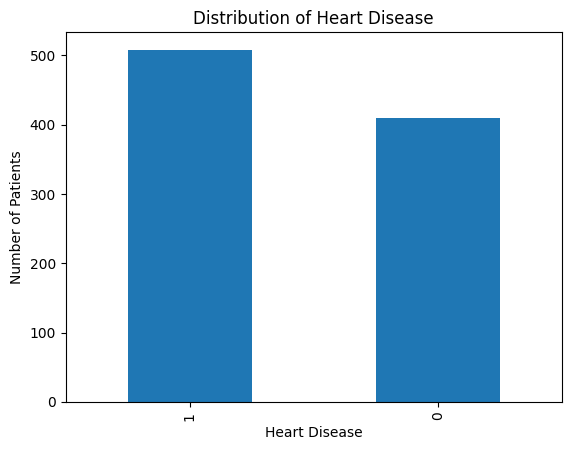

In [ ]:
# showing the number of patients with and without heart disease
import matplotlib.pyplot as plt

df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

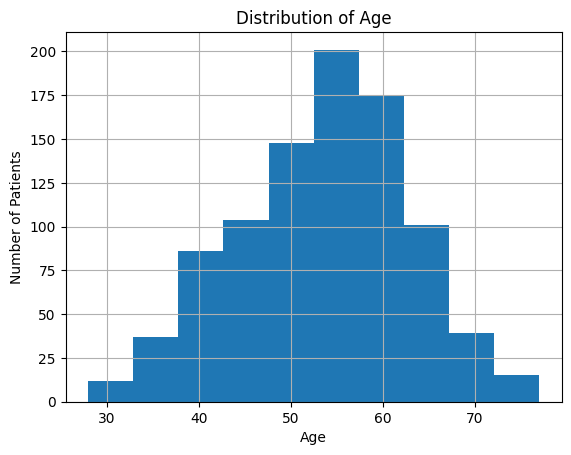

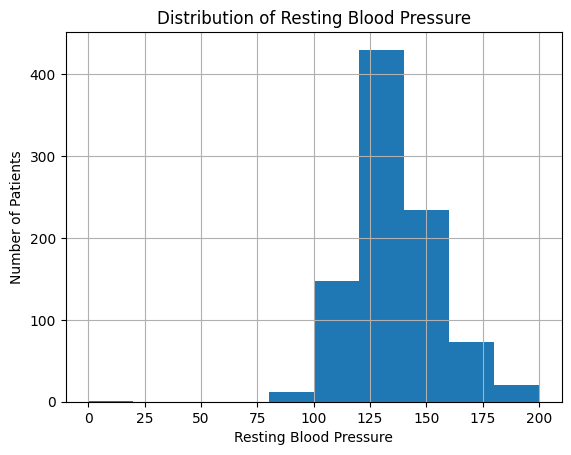

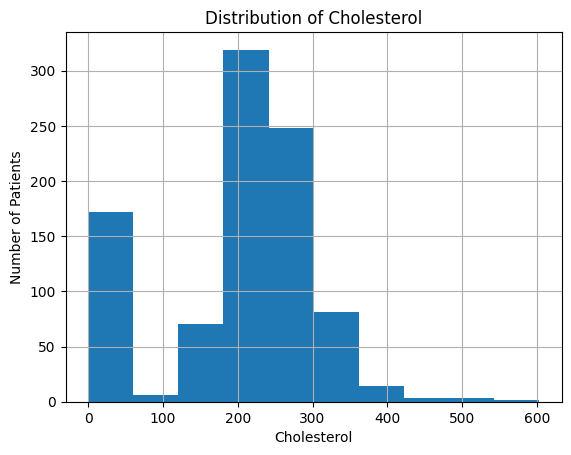

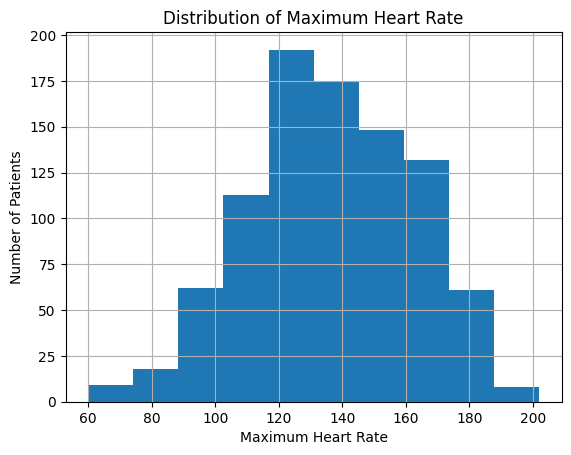

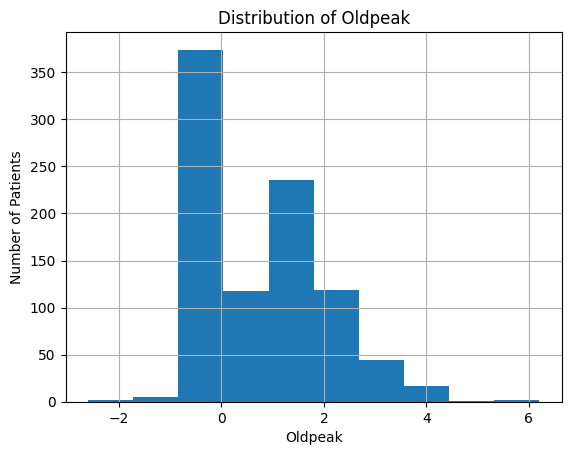

In [ ]:
# The Age Range of The Patients
df["Age"].hist()

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

# Showing The Distribution of Blood Pressure
df["RestingBP"].hist()

plt.title("Distribution of Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

# Showing The Distribution of Cholesterol Measurements
df["Cholesterol"].hist()

plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")
plt.show()

# Shows The Range of Maximum Heart Rates Recorded
df["MaxHR"].hist()

plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")
plt.show()

# Showing The Distribution of ST Depression Values
df["Oldpeak"].hist()

plt.title("Distribution of Oldpeak")
plt.xlabel("Oldpeak")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
# Creating a copy of the original dataset so that the original data remains unchanged
df_clean = df.copy()

In [ ]:
# Checking for Duplicate Rows
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


I checked for duplicate rows because duplicate patient records could cause some observations to be counted more than once and could bias the analysis or machine-learning model.

Only exact duplicate rows are removed. I do not remove similar-looking patients because two different patients can legitimately have the same health measurements.

Hence no duplicate rows were found, so no records were removed at this stage. Keeping all unique observations ensures that potentially useful patient information is retained.

In [ ]:
# Checking for Missing Value
missing = df_clean.isnull().sum()
missing

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


I checked each column for missing values and found no missing values. Therefore, no rows or values were removed or filled.

In [ ]:
#Examining Numerical Variables For Unusual Values
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

df_clean[numeric_columns].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000


I examined the numerical variables for unusual or potentially invalid values. I did not automatically remove outliers because an unusual medical measurement is not necessarily an error. Removing observations without evidence that they are incorrect could eliminate genuine patient information.


In [ ]:
# Checking for Suspicious Zero Value
for col in numeric_columns:
    print(f"\n{col}")
    print("Number of zeros:", (df_clean[col] == 0).sum())


Age
Number of zeros: 0

RestingBP
Number of zeros: 1

Cholesterol
Number of zeros: 172

MaxHR
Number of zeros: 0

Oldpeak
Number of zeros: 368

HeartDisease
Number of zeros: 410


*Oldpeak* and *HeartDisease* is perfectly valid; it means no ST depression was recorded.
FastingBS is technically represented as a number (0 or 1), but it is actually a binary/categorical variable in this dataset

In [ ]:
# Identifying the Row with a Zero Value in RestingBP
df_clean[df_clean["RestingBP"] == 0]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [ ]:
# Identifying the Row with a Zero Value in Cholesterol
df_clean[df_clean["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


since there are zero values in those columns, I recommend treating them as invalid/missing measurements, rather than assuming that they are genuine measurements.

In [ ]:
# Replacing those specific zero values with NaN.
import numpy as np

df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

In [ ]:
# To check how many i created
df_clean[["RestingBP", "Cholesterol"]].isnull().sum()

,0
RestingBP,1
Cholesterol,172


I checked zero values separately rather than treating every zero as missing. A value of zero is valid for variables such as FastingBS and Oldpeak, but a zero RestingBP or Cholesterol measurement is not physiologically plausible and is therefore treated as an invalid/missing measurement.

I did not drop these patient records because the other information in the records may still be useful. Instead, these specific invalid values were converted to missing values so that they can be handled appropriately.

In [ ]:
#Using The Median for the affected columns
import numpy as np

df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

df_clean["RestingBP"] = df_clean["RestingBP"].fillna(
    df_clean["RestingBP"].median()
)

df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(
    df_clean["Cholesterol"].median()
)

In [ ]:
''' PRINTING OUT THE ORIGINAL SHAPE,CLEANED SHAPE,
 MISSING VALUE AND DUPLICATE ROWS AND ALSO
 CHECKING IF THOSE ROWS WITH INVALID ZERO VALUE HAVE BEEN REPLACED WITH MEDIAN'''

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicates:", df_clean.duplicated().sum())

Original shape: (918, 12)
Cleaned shape: (918, 12)

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicates: 0


In [ ]:
# Identifying if the Row with a Zero Value in RestingBP still remain
df_clean[df_clean["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [ ]:
# Identifying if the Row with a Zero Value in Cholesterol still remain
df_clean[df_clean["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


I checked zero values individually rather than treating all zeros as missing. Zero is a valid value for variables such as FastingBS and Oldpeak. However, a zero value for RestingBP or Cholesterol is not a plausible physiological measurement, so these values were treated as invalid/missing.

I replaced only these specific invalid values with the median of their respective columns. The median was chosen because it is less affected by extreme values than the mean. I did not drop the entire patient records because their other information may still be useful.

### Final Cleaning Summary

The dataset was cleaned by checking for missing values, duplicate records, invalid measurements, and categorical values. No rows were unnecessarily dropped. Valid zero values were retained, while potentially invalid zero measurements in RestingBP and Cholesterol were handled separately. This approach avoids blanket data-filling methods and preserves as much valid patient information as possible.

In [ ]:
df_clean

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


**PART 2: FEATURE ENGINEERING AND ENCODING**

In [ ]:
# Feature 1 - Age Group
# creating AgeGroup by converting the continuous Age variable into ranges

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 40, 50, 60, 100],
    labels=["Under 40", "40-49", "50-59", "60+"]
)

df_clean[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,40,Under 40
1,49,40-49
2,37,Under 40
3,48,40-49
4,54,50-59


### Feature 1: Age Group
The business reasoning is that grouping patients into age segments makes it easier to identify and communicate patterns between different age groups. This also provides a simpler categorical feature that a machine-learning model can use alongside the original Age variable.

In [ ]:
# Maximum Heart Rate per Age
'''creating a ratio that combines two existing variables
 and provides a relative measure of maximum heart rate based on age'''

df_clean["MaxHR_per_Age"] = df_clean["MaxHR"] / df_clean["Age"]

df_clean[["Age", "MaxHR", "MaxHR_per_Age"]].head()

,Age,MaxHR,MaxHR_per_Age
0,40,172,4.300000
1,49,156,3.183673
2,37,98,2.648649
3,48,108,2.250000
4,54,122,2.259259


### Feature 2: Maximum Heart Rate per Age

I created MaxHR_per_Age by dividing MaxHR by Age. This creates a ratio that combines two existing variables and provides a relative measure of maximum heart rate based on age. The business reasoning is that relationships between variables may reveal patterns that are not as obvious when each variable is considered separately.

In [ ]:
# comparing Oldpeak values relative to a patient's age
df_clean["Oldpeak_Per_Age"] = df_clean["Oldpeak"] / df_clean["Age"]

df_clean[["Age", "Oldpeak", "Oldpeak_Per_Age"]].head()

,Age,Oldpeak,Oldpeak_Per_Age
0,40,0.0,0.000000
1,49,1.0,0.020408
2,37,0.0,0.000000
3,48,1.5,0.031250
4,54,0.0,0.000000


### Feature 3: Oldpeak per Age
The Business reasoning is that it provide an additional variable for exploring relationships in the data and determining whether age-related differences in Oldpeak are associated with the target variable, HeartDisease

In [ ]:
# CHECKING ALL THE THREE NEW FEATURES
df_clean[[
    "Age",
    "AgeGroup",
    "MaxHR",
    "MaxHR_per_Age",
    "Oldpeak",
    "Oldpeak_Per_Age"
]].head(10)

,Age,AgeGroup,MaxHR,MaxHR_per_Age,Oldpeak,Oldpeak_Per_Age
0,40,Under 40,172,4.300000,0.0,0.000000
1,49,40-49,156,3.183673,1.0,0.020408
2,37,Under 40,98,2.648649,0.0,0.000000
3,48,40-49,108,2.250000,1.5,0.031250
4,54,50-59,122,2.259259,0.0,0.000000
5,39,Under 40,170,4.358974,0.0,0.000000
6,45,40-49,170,3.777778,0.0,0.000000
7,54,50-59,142,2.629630,0.0,0.000000
8,37,Under 40,130,3.513514,1.5,0.040541
9,48,40-49,120,2.500000,0.0,0.000000


In [ ]:
# Label encoding for binary categorical columns
df_clean["Sex"] = df_clean["Sex"].map({"M": 1, "F": 0})
df_clean["ExerciseAngina"] = df_clean["ExerciseAngina"].map({"Y": 1, "N": 0})

# One-hot encoding for categorical columns with more than two categories
df_clean = pd.get_dummies(
    df_clean,
    columns=["ChestPainType", "RestingECG", "ST_Slope"],
    drop_first=True,
    dtype=int
)

# Encode target variable
df_clean["HeartDisease"] = df_clean["HeartDisease"].astype(int)

df_clean.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,AgeGroup,MaxHR_per_Age,Oldpeak_Per_Age,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,Under 40,4.300000,0.000000,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,40-49,3.183673,0.020408,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,Under 40,2.648649,0.000000,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,40-49,2.250000,0.031250,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,50-59,2.259259,0.000000,0,1,0,1,0,0,1
5,39,1,120.0,339.0,0,170,0,0.0,0,Under 40,4.358974,0.000000,0,1,0,1,0,0,1
6,45,0,130.0,237.0,0,170,0,0.0,0,40-49,3.777778,0.000000,1,0,0,1,0,0,1
7,54,1,110.0,208.0,0,142,0,0.0,0,50-59,2.629630,0.000000,1,0,0,1,0,0,1
8,37,1,140.0,207.0,0,130,1,1.5,1,Under 40,3.513514,0.040541,0,0,0,1,0,1,0
9,48,0,120.0,284.0,0,120,0,0.0,0,40-49,2.500000,0.000000,1,0,0,1,0,0,1


In [ ]:
df_clean2 = df_clean.copy()
df_clean2.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,AgeGroup,MaxHR_per_Age,Oldpeak_Per_Age,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,Under 40,4.300000,0.000000,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,40-49,3.183673,0.020408,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,Under 40,2.648649,0.000000,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,40-49,2.250000,0.031250,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,50-59,2.259259,0.000000,0,1,0,1,0,0,1
5,39,1,120.0,339.0,0,170,0,0.0,0,Under 40,4.358974,0.000000,0,1,0,1,0,0,1
6,45,0,130.0,237.0,0,170,0,0.0,0,40-49,3.777778,0.000000,1,0,0,1,0,0,1
7,54,1,110.0,208.0,0,142,0,0.0,0,50-59,2.629630,0.000000,1,0,0,1,0,0,1
8,37,1,140.0,207.0,0,130,1,1.5,1,Under 40,3.513514,0.040541,0,0,0,1,0,1,0
9,48,0,120.0,284.0,0,120,0,0.0,0,40-49,2.500000,0.000000,1,0,0,1,0,0,1


**Categorical Encoding**

I encoded every categorical variable so that the dataset can be used effectively for analysis and machine learning models.

1. **Sex: Label Encoding**

Sex contains only two categories: Male (M) and Female (F). I used label encoding, assigning M = 1 and F = 0. Since there are only two categories, this provides a simple binary representation without creating unnecessary columns.

2. **ExerciseAngina: Label Encoding**

ExerciseAngina also has only two categories: Yes (Y) and No (N). I encoded Y = 1 and N = 0 because it is a binary variable and label encoding is appropriate.

3. **ChestPainType: One-Hot Encoding**

ChestPainType has multiple categories, so I used one-hot encoding rather than assigning numerical values. This prevents the encoded values from implying an artificial ranking between the different chest pain categories.

4. **RestingECG: One-Hot Encoding**

RestingECG contains multiple categories, so one-hot encoding was used. Each category is represented by a separate binary column without creating an artificial order.

5. **ST_Slope: One-Hot Encoding**

ST_Slope has multiple categorical values, so I used one-hot encoding. This allows each category to be represented independently.

Why drop_first=True?

I used drop_first=True for the multi-category variables to remove one dummy column from each categorical variable. The remaining columns still contain enough information to determine the original category, while avoiding redundant dummy variables and reducing the risk of multicollinearity in models that are sensitive to it.

Target variable: HeartDisease

HeartDisease is already binary, with 0 and 1 representing the two target classes, so no additional one-hot encoding is necessary.

In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_target = ["HeartDisease"]
numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

scaler = StandardScaler()

df_clean2[numeric_features] = scaler.fit_transform(
    df_clean2[numeric_features]
)

df_clean2[numeric_features]
Scaled= df_clean2[numeric_features]
Scaled


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
0,-1.433140,0.415002,0.858035,1.382928,-0.832432
1,-0.478484,1.527329,-1.184227,0.754157,0.105664
2,-1.751359,-0.141161,0.745617,-1.525138,-0.832432
3,-0.584556,0.303769,-0.547191,-1.132156,0.574711
4,0.051881,0.971166,-0.903182,-0.581981,-0.832432
...,...,...,...,...,...
913,-0.902775,-1.253488,0.389626,-0.188999,0.293283
914,1.536902,0.637468,-0.940654,0.164684,2.357094
915,0.370100,-0.141161,-2.102308,-0.857069,0.293283
916,0.370100,-0.141161,-0.134991,1.461525,-0.832432


In [ ]:
target = df_clean2[numeric_target]
target

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


**Feature Scaling**

I chose StandardScaler to scale the numerical features in the dataset.

StandardScaler transforms the features so that they have a mean of approximately 0 and a standard deviation of 1. This is useful because the dataset contains features measured on very different scales. For example, Age, RestingBP, Cholesterol, MaxHR, and Oldpeak have different ranges and units.

Standardizing the features prevents variables with larger numerical values from having an unnecessarily greater influence on models that are sensitive to feature scale.

I chose StandardScaler instead of MinMaxScaler because StandardScaler is generally suitable when the numerical features have different ranges and may contain extreme observations. The dataset contains some relatively high Cholesterol and other numerical values, so StandardScaler is a reasonable choice for bringing the features onto a comparable scale.

The HeartDisease target variable is excluded from scaling because it is the target, not an input feature.

Since i used one-hot encoding, i do not need to standardize those binary 0/1 columns. A cleaner approach is to scale only the continuous numerical features

**PART 3 : CLUSTERING ANALYSIS**

In [ ]:
# Importing KMeans and silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    # Initialize K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model and predict clusters
    labels = kmeans.fit_predict(Scaled)

    # Record inertia
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score
    score = silhouette_score(Scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, "
          f"Inertia = {kmeans.inertia_:.2f}, "
          f"Silhouette Score = {score:.4f}")

K = 2, Inertia = 3535.35, Silhouette Score = 0.2175
K = 3, Inertia = 3095.37, Silhouette Score = 0.1779
K = 4, Inertia = 2770.84, Silhouette Score = 0.1813
K = 5, Inertia = 2511.63, Silhouette Score = 0.1866
K = 6, Inertia = 2343.40, Silhouette Score = 0.1642
K = 7, Inertia = 2209.74, Silhouette Score = 0.1596
K = 8, Inertia = 2093.19, Silhouette Score = 0.1606
K = 9, Inertia = 1993.51, Silhouette Score = 0.1545
K = 10, Inertia = 1922.00, Silhouette Score = 0.1542


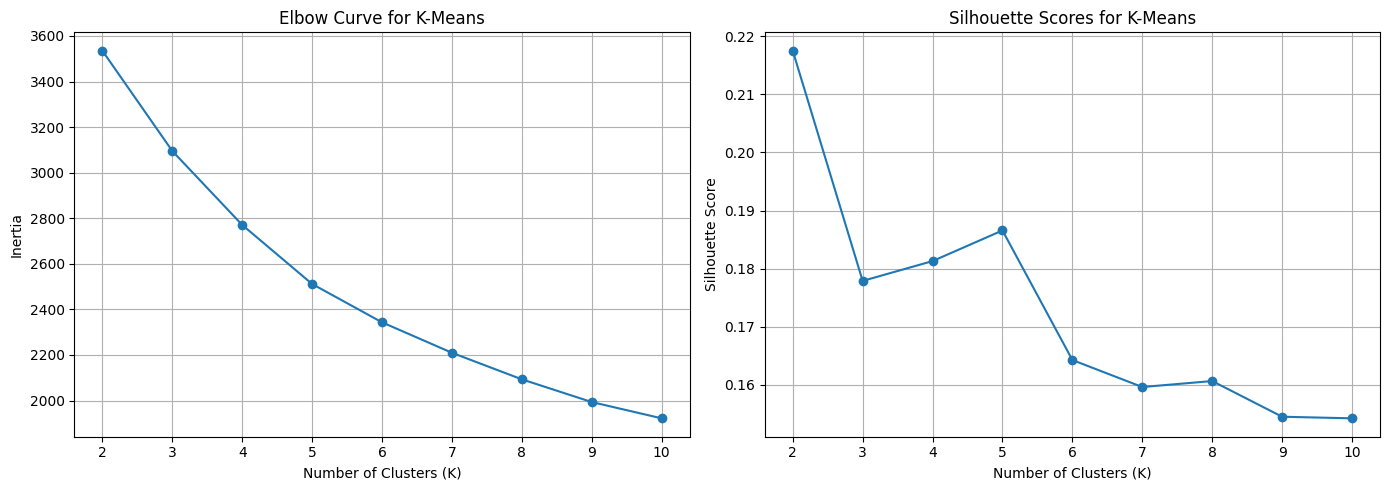

In [ ]:

# Create a figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------
# Elbow Curve
# ---------------------------
axes[0].plot(
    list(K_range),
    inertia,
    marker='o'
)

axes[0].set_title('Elbow Curve for K-Means')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))
axes[0].grid(True)

# Silhouette Scores
axes[1].plot(
    list(K_range),
    silhouette_scores,
    marker='o'
)

axes[1].set_title('Silhouette Scores for K-Means')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True)

plt.tight_layout()
plt.show()

The K-Means algorithm was evaluated for values of K ranging from 2 to 10 using both the elbow method and silhouette scores. The inertia decreased as the number of clusters increased, from 3535.35 at K = 2 to 1922.00 at K = 10. However, the reduction in inertia becomes progressively smaller as K increases, indicating diminishing returns from adding more clusters.

The silhouette scores provide a second signal for selecting K. The highest silhouette score was obtained at K = 2, with a score of 0.2175. The score decreased substantially at K = 3 (0.1779) and remained relatively low for the other values of K, with the highest subsequent value being 0.1866 at K = 5.

Based on both measures, K = 2 was selected as the final number of clusters. Although the silhouette score is relatively low, K=2 is the best of the tested choices, but the dataset does not exhibit particularly strong natural clustering., while the inertia curve indicates that increasing K provides diminishing improvements in within-cluster compactness.

In [ ]:
 # Add cluster labels to a copy of the data
Scaled_clean = Scaled.copy()
Scaled_clean["Cluster"] = labels
print(Scaled_clean["Cluster"].value_counts().sort_index())


Cluster
0    111
1     99
2     75
3    122
4     83
5     14
6    126
7     61
8    116
9    111
Name: count, dtype: int64


In [ ]:
# Calculate the mean of each feature by cluster
cluster_means = Scaled_clean.groupby('Cluster')[numeric_features].mean()

# Round the results for easier reading
cluster_means = cluster_means.round(3)

display(cluster_means)

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
Cluster,,,,,
0,-0.009,0.305,-0.862,0.439,-0.537
1,-0.397,-0.632,-0.130,0.124,0.975
2,0.649,1.763,-0.123,-0.677,-0.142
3,0.992,-0.024,-0.321,-0.820,0.636
4,0.617,0.681,1.220,0.104,0.110
5,-0.274,-0.014,4.176,-0.018,-0.075
6,-1.448,-0.690,-0.480,0.909,-0.705
7,0.561,0.816,0.071,-0.178,2.243
8,0.157,-0.680,-0.084,-1.084,-0.717


In [ ]:
from sklearn.decomposition import PCA

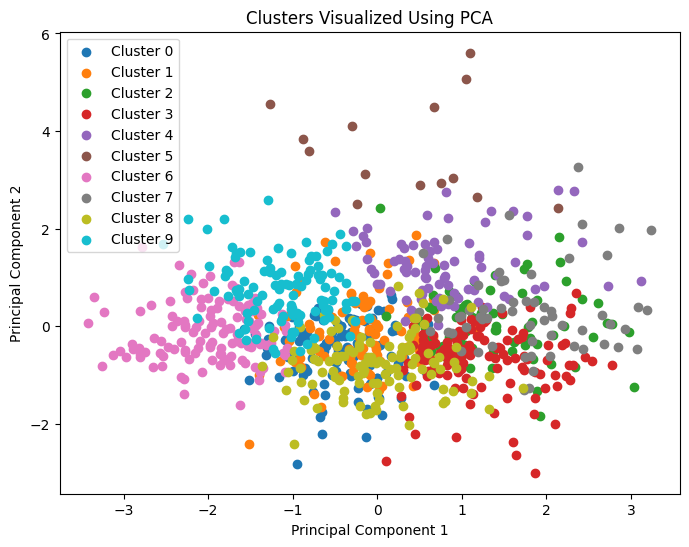

In [ ]:

 #Apply PCA and reduce to 2 dimensions
pca = PCA(n_components=2)
pca = pca.fit_transform(Scaled)

# Create a dataframe containing the two principal components
pca_df = pd.DataFrame(
    pca,
    columns=["PC1", "PC2"],
    index=df_clean.index
)

# Add the cluster labels
pca_df["Cluster"] = Scaled_clean["Cluster"].values

# Plot the clusters
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clusters Visualized Using PCA")
plt.legend()
plt.show()

**PART 4: CLASSIFICATION**

In [ ]:
X_scaled  = Scaled
y = df["HeartDisease"]
# Unscaled
X_unscaled = df[['Age', 'RestingBP', 'Cholesterol','MaxHR', 'Oldpeak']]
y = df["HeartDisease"]

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Define X and y
# --------------------------------------------------

X_unscaled = df[
    ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
]

y = df["HeartDisease"]


# --------------------------------------------------
# 2. Split the UNSCALED data
# --------------------------------------------------

X_unscaled_train, X_unscaled_test, y_train, y_test = train_test_split(
    X_unscaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 3. Create the scaler
# --------------------------------------------------

scaler = StandardScaler()


# --------------------------------------------------
# 4. Fit scaler ONLY on training data
# --------------------------------------------------

X_train_scaled = scaler.fit_transform(X_unscaled_train)


# --------------------------------------------------
# 5. Transform test data using the SAME scaler
# --------------------------------------------------

X_test_scaled = scaler.transform(X_unscaled_test)


# --------------------------------------------------
# 6. Convert back to DataFrames
# --------------------------------------------------

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_unscaled.columns,
    index=X_unscaled_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_unscaled.columns,
    index=X_unscaled_test.index
)


# Check
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_scaled: (734, 5)
X_test_scaled: (184, 5)
y_train: (734,)
y_test: (184,)


I will be training the following classifiers
1. Logistic Regression
2. KNeighborsClassifier
3. Decision Tree Classifier



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:
# Stratified 5-Fold Cross-Validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define models

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

# Metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

#  Cross-validation results

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_unscaled,
        y,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),

        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC SD": scores["test_roc_auc"].std()
    })


# --------------------------------------------------
# 6. Comparison table
# --------------------------------------------------

comparison = pd.DataFrame(results)

print(comparison.round(2))

                 Model  Accuracy Mean  Accuracy SD  Precision Mean  \
0  Logistic Regression           0.76         0.03            0.78   
1                  KNN           0.74         0.01            0.77   
2        Decision Tree           0.68         0.03            0.72   

   Precision SD  Recall Mean  Recall SD  F1 Mean  F1 SD  ROC AUC Mean  \
0          0.04         0.79       0.03     0.78   0.03          0.83   
1          0.01         0.76       0.02     0.77   0.01          0.80   
2          0.02         0.69       0.07     0.70   0.04          0.68   

   ROC AUC SD  
0        0.03  
1        0.02  
2        0.03  


In [ ]:
report = pd.DataFrame({
    "Model": comparison["Model"],

    "Accuracy": (
        comparison["Accuracy Mean"].round(2).astype(str)
        + " ± "
        + comparison["Accuracy SD"].round(2).astype(str)
    ),

    "Precision": (
        comparison["Precision Mean"].round(2).astype(str)
        + " ± "
        + comparison["Precision SD"].round(2).astype(str)
    ),

    "Recall": (
        comparison["Recall Mean"].round(2).astype(str)
        + " ± "
        + comparison["Recall SD"].round(2).astype(str)
    ),

    "F1": (
        comparison["F1 Mean"].round(2).astype(str)
        + " ± "
        + comparison["F1 SD"].round(2).astype(str)
    ),

    "ROC AUC": (
        comparison["ROC AUC Mean"].round(2).astype(str)
        + " ± "
        + comparison["ROC AUC SD"].round(2).astype(str)
    )
})

report = report.set_index("Model")

report

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.76 ± 0.03,0.78 ± 0.04,0.79 ± 0.03,0.78 ± 0.03,0.83 ± 0.03
KNN,0.74 ± 0.01,0.77 ± 0.01,0.76 ± 0.02,0.77 ± 0.01,0.8 ± 0.02
Decision Tree,0.68 ± 0.03,0.72 ± 0.02,0.69 ± 0.07,0.7 ± 0.04,0.68 ± 0.03


Logistic Regression: Provides a simple baseline for classification and works well with scaled features.

KNN: Uses distances between observations, making it useful for evaluating the effect of feature scaling.

Decision Tree: Can model nonlinear relationships and generally does not require feature scaling.


Logistic Regression
[[293 117]
 [107 401]]


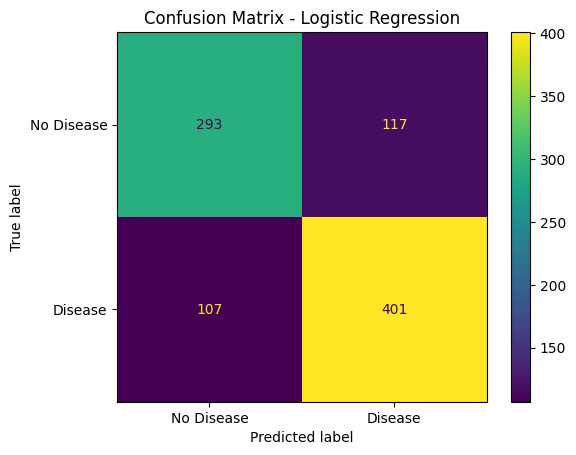


KNN
[[295 115]
 [122 386]]


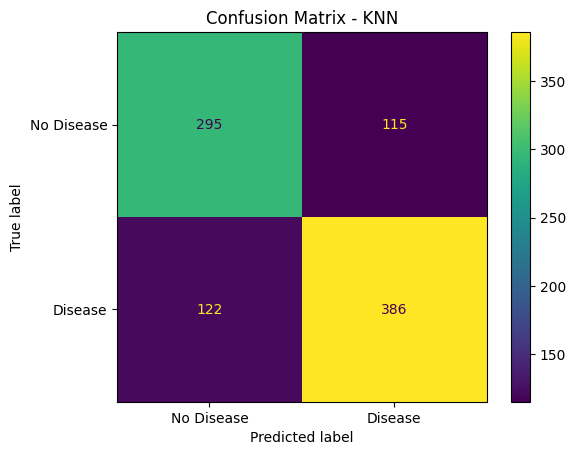


Decision Tree
[[274 136]
 [159 349]]


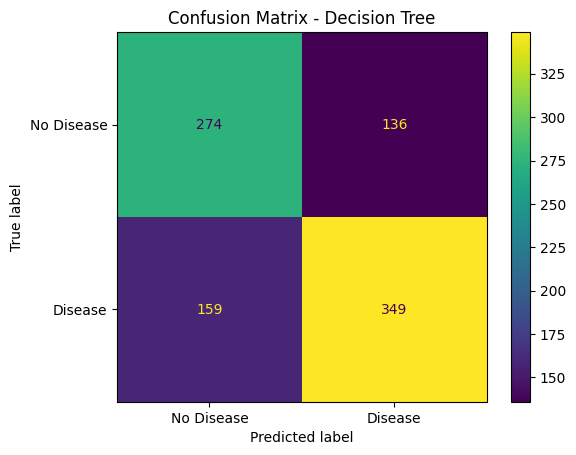

In [ ]:
for name, model in models.items():

    # Generate out-of-fold predictions
    y_pred = cross_val_predict(
        model,
        X_unscaled,
        y,
        cv=skf,
        method="predict"
    )

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)

    print(f"\n{name}")
    print(cm)

    # Plot
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    ).plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

**PART 5 : IMBALANCE HANDLING**

In [ ]:

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, confusion_matrix

In [ ]:
# Models with SMOTE
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", KNeighborsClassifier())
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}

In [ ]:
print("Original class distribution:")
print(y.value_counts())

Original class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [ ]:
# Business costs
C_FN = 5
C_FP = 1

# Inner CV for obtaining out-of-fold probabilities
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold_results = {}

for name, model in models.items():

    # Get out-of-fold probabilities
    y_prob = cross_val_predict(
        model,
        X_unscaled,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    # Precision-recall curve
    precision, recall, thresholds = precision_recall_curve(
        y,
        y_prob
    )

    # Find threshold with minimum business cost
    costs = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y,
            y_pred,
            labels=[0, 1]
        ).ravel()

        total_cost = (
            C_FP * fp +
            C_FN * fn
        )

        costs.append(total_cost)

    # Select threshold with lowest cost
    best_index = np.argmin(costs)
    best_threshold = thresholds[best_index]

    threshold_results[name] = best_threshold

    print(f"{name}")
    print(f"Best threshold: {best_threshold:.3f}")
    print(f"Minimum business cost: {costs[best_index]}")
    print()

KNN
Best threshold: 0.000
Minimum business cost: 410

Logistic Regression
Best threshold: 0.126
Minimum business cost: 396

Decision Tree
Best threshold: 0.000
Minimum business cost: 410



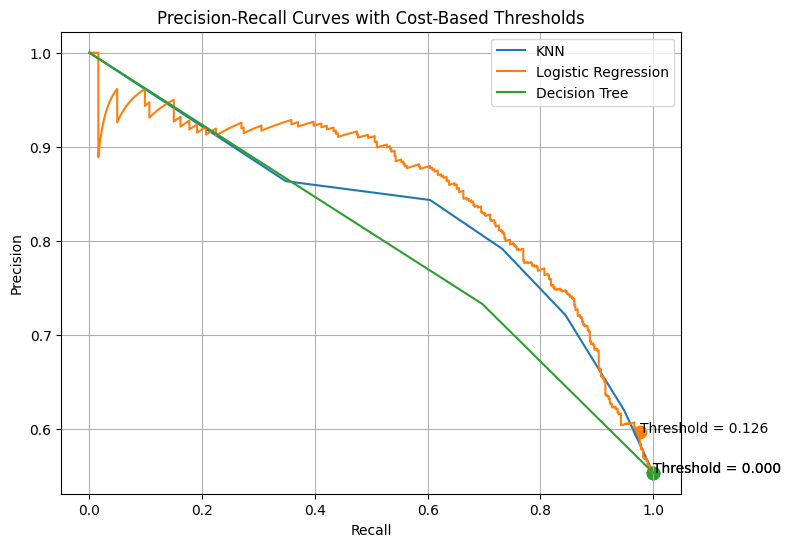

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = cross_val_predict(
        model,
        X_unscaled,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y,
        y_prob
    )

    threshold = threshold_results[name]

    # Find closest threshold on the PR curve
    idx = np.argmin(
        np.abs(thresholds - threshold)
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

    plt.scatter(
        recall[idx],
        precision[idx],
        s=80
    )

    plt.annotate(
        f"Threshold = {threshold:.3f}",
        (recall[idx], precision[idx])
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves with Cost-Based Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for name, threshold in threshold_results.items():
    print(f"{name}: threshold = {threshold:.3f}")

KNN: threshold = 0.000
Logistic Regression: threshold = 0.126
Decision Tree: threshold = 0.000


In [ ]:
y_pred = (y_prob >= threshold).astype(int)

Threshold tuning was performed using precision-recall curves. A false negative was assigned a cost of 5, while a false positive was assigned a cost of 1, reflecting the assumption that failing to identify a patient with heart disease is more costly than incorrectly flagging a patient for further evaluation. The threshold minimizing the total business cost was selected for each model.

In [ ]:
# Class distribution
class_counts = y.value_counts()
class_percent = y.value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Class percentages:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


# ---------------------------------------------------------
# Models
# ---------------------------------------------------------

class_weight_models = {
    "KNN": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
        ,

    "Logistic Regression": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balance",
            random_state=42,
            max_iter=1000

            ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
        )
}


baseline_models = {
    "KNN": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Logistic Regression": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42)
}


smote_models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", KNeighborsClassifier())
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}


# ---------------------------------------------------------
# 5-fold stratified CV
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ---------------------------------------------------------
# Evaluation function
# ---------------------------------------------------------

def evaluate_model(model, X_unscaled, y, threshold=0.50):

    accuracy = []
    precision = []
    recall = []
    f1 = []
    auc = []

    for train_idx, test_idx in cv.split(X_unscaled, y):

        X_train = X_unscaled.iloc[train_idx]
        X_test = X_unscaled.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob >= threshold).astype(int)

        accuracy.append(
            accuracy_score(y_test, y_pred)
        )

        precision.append(
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        recall.append(
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        f1.append(
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        auc.append(
            roc_auc_score(y_test, y_prob)
        )

    return {
        "Accuracy": np.mean(accuracy),
        "Precision": np.mean(precision),
        "Recall": np.mean(recall),
        "F1": np.mean(f1),
        "ROC AUC": np.mean(auc)
    }


# ---------------------------------------------------------
# Compare baseline and SMOTE
# ---------------------------------------------------------

comparison = []

for name in baseline_models:

    # Baseline
    baseline_scores = evaluate_model(
        baseline_models[name],
        X_unscaled,
        y,
        threshold=0.50
    )

    comparison.append({
        "Model": name,
        "Technique": "Baseline",
        **baseline_scores
    })

    # SMOTE
    smote_scores = evaluate_model(
        smote_models[name],
        X_unscaled,
        y,
        threshold=0.50
    )

    comparison.append({
        "Model": name,
        "Technique": "SMOTE",
        **smote_scores
    })


comparison_table = pd.DataFrame(comparison)

comparison_table[
    ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
] = comparison_table[
    ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
].round(2)

comparison_table

,Model,Technique,Accuracy,Precision,Recall,F1,ROC AUC
0,KNN,Baseline,0.74,0.77,0.76,0.77,0.80
1,KNN,SMOTE,0.75,0.79,0.73,0.76,0.80
2,Logistic Regression,Baseline,0.76,0.78,0.79,0.78,0.83
3,Logistic Regression,SMOTE,0.76,0.80,0.75,0.77,0.83
4,Decision Tree,Baseline,0.68,0.72,0.69,0.70,0.68
5,Decision Tree,SMOTE,0.69,0.73,0.70,0.71,0.69


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import numpy as np


# Business cost
C_FN = 5
C_FP = 1

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ---------------------------------------------------------
# Find cost-sensitive threshold
# ---------------------------------------------------------

def find_best_threshold(y_true, y_prob):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    best_threshold = 0.5
    lowest_cost = np.inf

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        cost = C_FP * fp + C_FN * fn

        if cost < lowest_cost:
            lowest_cost = cost
            best_threshold = threshold

    return best_threshold


# ---------------------------------------------------------
# Evaluate SMOTE + threshold tuning
# ---------------------------------------------------------

threshold_results_table = []

for name, model in smote_models.items():

    fold_accuracy = []
    fold_precision = []
    fold_recall = []
    fold_f1 = []
    fold_auc = []

    for train_idx, test_idx in cv.split(X_unscaled, y):

        X_train = X_unscaled.iloc[train_idx]
        X_test = X_unscaled.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Fit SMOTE model on training fold
        model.fit(X_train, y_train)

        # Probabilities
        train_prob = model.predict_proba(X_train)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        # Tune threshold using training data
        threshold = find_best_threshold(
            y_train,
            train_prob
        )

        # Apply selected threshold to test fold
        y_pred = (
            test_prob >= threshold
        ).astype(int)

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

        fold_precision.append(
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        fold_f1.append(
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            )
        )

        # ROC AUC uses probabilities, not thresholded predictions
        fold_auc.append(
            roc_auc_score(y_test, test_prob)
        )

    threshold_results_table.append({
        "Model": name,
        "Technique": "SMOTE + Threshold",
        "Accuracy": np.mean(fold_accuracy),
        "Precision": np.mean(fold_precision),
        "Recall": np.mean(fold_recall),
        "F1": np.mean(fold_f1),
        "ROC AUC": np.mean(fold_auc)
    })


threshold_table = pd.DataFrame(
    threshold_results_table
)

threshold_table[
    ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
] = threshold_table[
    ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
].round(2)

threshold_table

,Model,Technique,Accuracy,Precision,Recall,F1,ROC AUC
0,KNN,SMOTE + Threshold,0.65,0.62,0.95,0.75,0.80
1,Logistic Regression,SMOTE + Threshold,0.57,0.56,0.99,0.72,0.83
2,Decision Tree,SMOTE + Threshold,0.69,0.73,0.70,0.71,0.69


Logistic Regression + SMOTE + cost-sensitive thresholding is the selected configuration because the stated cost prioritizes avoiding false negatives.

In [ ]:
from sklearn.dummy import DummyClassifier
# Create stratified dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

# Fit on training data
dummy.fit(X_train, y_train)

# Predictions and probabilities
y_dummy_pred = dummy.predict(X_test)
y_dummy_prob = dummy.predict_proba(X_test)[:, 1]

# Create DataFrame
dummy_results = pd.DataFrame({
    "Model": ["Stratified Dummy"],
    "Accuracy": [accuracy_score(y_test, y_dummy_pred)],
    "Precision": [precision_score(y_test, y_dummy_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_dummy_pred, zero_division=0)],
    "F1": [f1_score(y_test, y_dummy_pred, zero_division=0)],
    "ROC AUC": [roc_auc_score(y_test, y_dummy_prob)]
})

# Round results
dummy_results = dummy_results.round(2)

dummy_results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Stratified Dummy,0.5,0.55,0.59,0.57,0.49


**PART 6 : THE TIE IN**

In [ ]:
#Combine clusters with target


cluster_results = pd.DataFrame({
    "Cluster": labels,
    "HeartDisease": target["HeartDisease"]
})


cluster_target_summary = cluster_results.groupby("Cluster").agg(
    Cluster_Size=("HeartDisease", "size"),
    Positive_Cases=("HeartDisease", "sum"),
    Positive_Class_Rate=("HeartDisease", "mean")
)

# Convert rate from proportion to percentage
cluster_target_summary["Positive_Class_Rate"] *= 100

cluster_target_summary = cluster_target_summary.round(2)

display(cluster_target_summary)


,Cluster_Size,Positive_Cases,Positive_Class_Rate
Cluster,,,
0,111,32,28.83
1,99,70,70.71
2,75,60,80.00
3,122,108,88.52
4,83,47,56.63
5,14,8,57.14
6,126,30,23.81
7,61,56,91.80
8,116,65,56.03


The results show that some clusters have a much higher positive-class rate than others, which suggests that the clustering has captured meaningful structure related to the HeartDisease label

**The strongest clusters are:**

Cluster 7: 91.80% positive
            


Cluster 3: 88.52% positive
            


Cluster 2: 80.00% positive
            


Cluster 1: 70.71% positive

Several clusters showed strong differences in their positive-class rates, suggesting that the clustering captured meaningful structure related to the HeartDisease label. Clusters 7 and 3 had the highest positive-class rates at 91.80% and 88.52%, respectively, followed by Cluster 2 at 80.00% and Cluster 1 at 70.71%. In contrast, Cluster 6 had a positive-class rate of only 23.81%, while Clusters 0 and 9 had rates of 28.83%. Since K-Means was performed without using the target variable, these differences suggest that the underlying patient characteristics used for clustering contain information associated with heart disease status. However, the clusters should be interpreted as patient subgroups rather than direct predictors, because K-Means is an unsupervised method

**PART 7 : CONCLUSION AND RECOMMENDATION**

**DEPTH TRACK** : IMBALANCE WAS WORKED ON

In [ ]:
# ============================================================
# BASELINE vs CLASS WEIGHTING vs SMOTE
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


# ------------------------------------------------------------
# 1. STRATIFIED 5-FOLD CV
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 2. SCORING METRICS
# ------------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ------------------------------------------------------------
# 3. DEFINE MODELS
# ------------------------------------------------------------

models = {

    # ========================================================
    # LOGISTIC REGRESSION
    # ========================================================

    "Logistic Regression - Baseline": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "Logistic Regression - Class Weight": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]),

    "Logistic Regression - SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),


    # ========================================================
    # KNN
    # ========================================================

    "KNN - Baseline": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    # KNN does NOT support class_weight.
    # Therefore there is no KNN - Class Weight model.

    "KNN - SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", KNeighborsClassifier())
    ]),


    # ========================================================
    # DECISION TREE
    # ========================================================

    "Decision Tree - Baseline": DecisionTreeClassifier(
        random_state=42
    ),

    "Decision Tree - Class Weight": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree - SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ])
}


# ------------------------------------------------------------
# 4. RUN 5-FOLD CROSS-VALIDATION
# ------------------------------------------------------------

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_unscaled,
        y,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),

        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC SD": scores["test_roc_auc"].std()
    })


# ------------------------------------------------------------
# 5. CREATE COMPARISON TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame(results)

print("BASELINE vs CLASS WEIGHTING vs SMOTE")
display(comparison.round(2))

BASELINE vs CLASS WEIGHTING vs SMOTE


,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC AUC Mean,ROC AUC SD
0,Logistic Regression - Baseline,0.76,0.03,0.78,0.04,0.79,0.03,0.78,0.03,0.83,0.03
1,Logistic Regression - Class Weight,0.76,0.03,0.81,0.04,0.75,0.02,0.78,0.03,0.83,0.03
2,Logistic Regression - SMOTE,0.76,0.03,0.80,0.04,0.75,0.02,0.77,0.02,0.83,0.03
3,KNN - Baseline,0.74,0.01,0.77,0.01,0.76,0.02,0.77,0.01,0.80,0.02
4,KNN - SMOTE,0.75,0.01,0.79,0.02,0.73,0.01,0.76,0.01,0.80,0.02
5,Decision Tree - Baseline,0.68,0.03,0.72,0.02,0.69,0.07,0.70,0.04,0.68,0.03
6,Decision Tree - Class Weight,0.69,0.02,0.72,0.01,0.70,0.07,0.71,0.04,0.68,0.02
7,Decision Tree - SMOTE,0.69,0.02,0.73,0.02,0.70,0.06,0.71,0.03,0.69,0.02



**PART 7 : CONCLUSION AND RECOMMENDATION**

Based on these results, I would deploy Logistic Regression with class weighting because it achieved the highest precision (0.81), while maintaining strong F1 (0.78) and ROC AUC (0.83), with stable performance across folds. With another month, I would focus on hyperparameter tuning, feature engineering, threshold optimisation, and external validation. The clustering results could reveal hidden customer segments or behavioural patterns that the classifier missed because classification predicts predefined labels, while clustering can uncover previously unknown groups. The hardest decision was choosing between baseline Logistic Regression, class weighting, and SMOTE, since all three achieved similar accuracy and ROC AUC, but class weighting provided the best precision without sacrificing overall F1 performance.

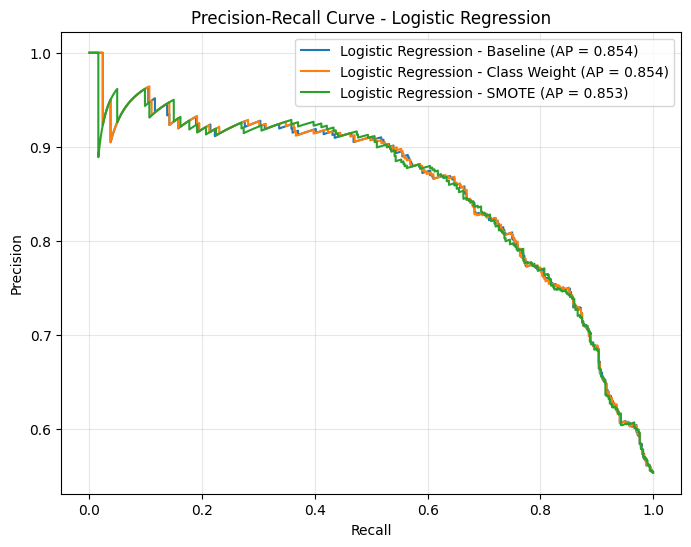

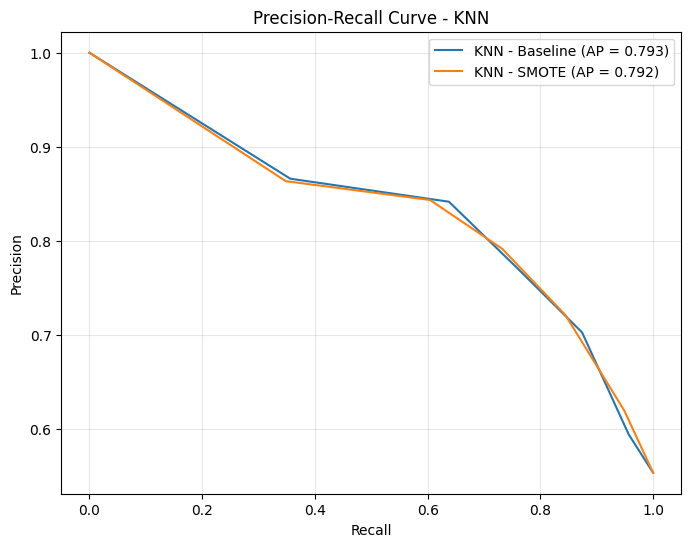

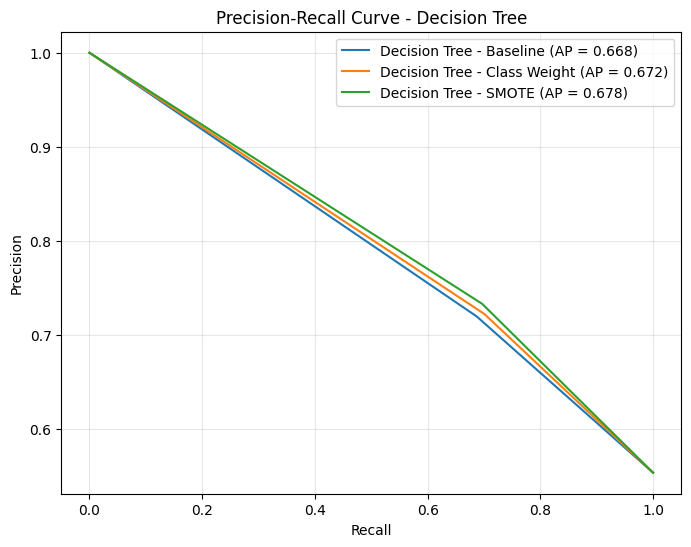

In [ ]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Store out-of-fold probabilities
oof_probabilities = {}

for name, model in models.items():

    y_prob = cross_val_predict(
        model,
        X_unscaled,
        y,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_probabilities[name] = y_prob


# ============================================================
# PLOT PR CURVES
# ============================================================

for model_type in [
    "Logistic Regression",
    "KNN",
    "Decision Tree"
]:

    plt.figure(figsize=(8, 6))

    for name, y_prob in oof_probabilities.items():

        if name.startswith(model_type):

            precision, recall, thresholds = precision_recall_curve(
                y,
                y_prob
            )

            ap = average_precision_score(
                y,
                y_prob
            )

            plt.plot(
                recall,
                precision,
                label=f"{name} (AP = {ap:.3f})"
            )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_type}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# ============================================================
# FINAL OPERATING POINT: DEFAULT THRESHOLD = 0.5
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

THRESHOLD = 0.5

# Example cost assumptions
COST_FP = 1
COST_FN = 5

final_results = []

for name, y_prob in oof_probabilities.items():

    # Apply default threshold of 0.5
    y_pred = (y_prob >= THRESHOLD).astype(int)

    # Confusion matrix components
    TP = np.sum((y == 1) & (y_pred == 1))
    TN = np.sum((y == 0) & (y_pred == 0))
    FP = np.sum((y == 0) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))

    # Cost
    total_cost = (
        FP * COST_FP +
        FN * COST_FN
    )

    final_results.append({
        "Model": name,
        "Threshold": THRESHOLD,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(
            y, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y, y_pred, zero_division=0
        ),
        "ROC AUC": roc_auc_score(y, y_prob),
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Total Cost": total_cost
    })


final_operating_point = pd.DataFrame(final_results)

display(
    final_operating_point.round(2)
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,TP,TN,FP,FN,Total Cost
0,Logistic Regression - Baseline,0.5,0.76,0.77,0.79,0.78,0.83,401,293,117,107,652
1,Logistic Regression - Class Weight,0.5,0.76,0.81,0.75,0.78,0.83,381,319,91,127,726
2,Logistic Regression - SMOTE,0.5,0.76,0.80,0.75,0.77,0.83,381,313,97,127,732
3,KNN - Baseline,0.5,0.74,0.77,0.76,0.77,0.80,386,295,115,122,725
4,KNN - SMOTE,0.5,0.75,0.79,0.73,0.76,0.80,372,312,98,136,778
5,Decision Tree - Baseline,0.5,0.68,0.72,0.69,0.70,0.68,349,274,136,159,931
6,Decision Tree - Class Weight,0.5,0.69,0.72,0.70,0.71,0.68,356,273,137,152,897
7,Decision Tree - SMOTE,0.5,0.69,0.73,0.70,0.71,0.69,354,281,129,154,899


**FINAL OPERATING POINT**
The default classification threshold of 0.5 was used as the final operating point. Predictions with a probability of at least 0.5 were classified as class 1, while probabilities below 0.5 were classified as class 0. The operating point was evaluated using precision, recall, F1-score, ROC-AUC, false positives, false negatives, and the specified misclassification costs. Total cost was calculated as the number of false positives multiplied by the false-positive cost plus the number of false negatives multiplied by the false-negative cost. This provides a transparent assessment of the trade-off between false positives and false negatives at the standard 0.5 threshold.


In [ ]:
end_time = time.time()

total_seconds = end_time - start_time
total_minutes = total_seconds / 60

print(f"Total runtime: {total_minutes:.2f} minutes")

Total runtime: 0.81 minutes


In [193]:
!pip freeze > requirements.txt